# OpenSourcePulse — Descriptive Exploratory Data Analysis

## GitHub Repository Intelligence System

**Course:** BACSE301 — Exploratory Data Analysis  
**Dataset:** 300 GitHub repositories  
**Analysis Period:** September 2025 – September 2026

### Objective

To explore repository popularity, development activity, community participation,
maintenance indicators, repository characteristics, and relationships among
these variables using systematic exploratory data analysis.

### Research Questions

1. Does repository popularity correspond to repository activity?
2. Which repository characteristics are associated with higher activity?
3. How do repository characteristics differ across programming languages?
4. How does repository age relate to activity and popularity?
5. What relationships exist among popularity, collaboration, maintenance,
   and development activity?

### EDA Workflow

**Data Understanding → Univariate Analysis → Bivariate Analysis →  
Multivariate Analysis → Statistical Analysis → Interpretation**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import skew, kurtosis

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
df = pd.read_csv(
    "../data/processed/repository_features_clean.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (300, 48)


In [6]:
df.head()

,repo_id,repo_name,owner,full_name,description,html_url,language,topics,license,created_at,updated_at,pushed_at,stars,forks,watchers,open_issues,size_kb,default_branch,is_fork,archived,repository_age_days,repository_age_years,days_since_update,days_since_push,contributors_count,total_contributions,top_contributor_contributions,top_contributor_share,commits_365d,active_months,peak_monthly_commits,mean_monthly_commits,monthly_commit_std,activity_consistency,status,collected_commits,fork_star_ratio,issues_per_star,commits_per_active_month,language_normalized,log1p_stars,log1p_forks,log1p_open_issues,log1p_size_kb,log1p_commits_365d,log1p_contributors_count,log1p_total_contributions,log1p_peak_monthly_commits
0,192904,pymc,pymc-devs,pymc-devs/pymc,Bayesian Modeling and Probabilistic Programmin...,https://github.com/pymc-devs/pymc,Python,bayesian-inference|mcmc|probabilistic-programm...,NOASSERTION,2009-05-05 09:43:50+00:00,2026-09-17 02:27:02+00:00,2026-09-14 17:31:40+00:00,9754,2301,9754,503,546029,main,False,False,6345,17.372,1,3,328.000,"7,558.000","1,028.000",0.136,280.000,13.000,48.000,21.538,13.220,1.000,success,280,0.236,0.052,21.538,python,9.186,7.742,6.223,13.210,5.638,5.796,8.930,3.892
1,374228,RestSharp,restsharp,restsharp/RestSharp,Simple REST and HTTP API Client for .NET,https://github.com/restsharp/RestSharp,C#,No topics specified,Apache-2.0,2009-11-16 02:01:45+00:00,2026-09-16 20:48:34+00:00,2026-09-07 22:42:25+00:00,9824,2299,9824,37,41466,dev,False,False,6150,16.838,1,10,266.000,"2,048.000",758.000,0.370,61.000,7.000,20.000,8.714,6.317,0.538,success,61,0.234,0.004,8.714,c#,9.193,7.741,3.638,10.633,4.127,5.587,7.625,3.045
2,443962,FluentValidation,FluentValidation,FluentValidation/FluentValidation,A popular .NET validation library for building...,https://github.com/FluentValidation/FluentVali...,C#,No topics specified,Apache-2.0,2009-12-20 19:17:03+00:00,2026-09-16 20:51:25+00:00,2026-09-09 12:55:43+00:00,9752,1276,9752,3,20025,main,False,False,6115,16.742,1,9,268.000,"2,452.000","2,056.000",0.838,27.000,10.000,6.000,2.700,1.567,0.769,success,27,0.131,0.000,2.700,c#,9.185,7.152,1.386,9.905,3.332,5.595,7.805,1.946
3,519832,mitmproxy,mitmproxy,mitmproxy/mitmproxy,An interactive TLS-capable intercepting HTTP p...,https://github.com/mitmproxy/mitmproxy,Python,debugging|http|http2|man-in-the-middle|mitmpro...,MIT,2010-02-16 04:10:13+00:00,2026-09-17 16:23:40+00:00,2026-09-10 06:52:11+00:00,45078,4730,45078,491,69290,main,False,False,6058,16.586,0,8,406.000,"10,847.000","4,021.000",0.371,210.000,12.000,32.000,17.500,8.980,0.923,success,210,0.105,0.011,17.500,python,10.716,8.462,6.198,11.146,5.352,6.009,9.292,3.497
4,747698,sinon,sinonjs,sinonjs/sinon,"Test spies, stubs and mocks for JavaScript.",https://github.com/sinonjs/sinon,JavaScript,javascript|sinon|stub|stubs|tdd|test-driven-de...,NOASSERTION,2010-06-29 21:15:32+00:00,2026-09-15 07:01:23+00:00,2026-09-10 22:36:25+00:00,9758,807,9758,66,45948,main,False,False,5924,16.219,3,7,337.000,"3,617.000",995.000,0.275,80.000,8.000,16.000,10.000,5.952,0.615,success,80,0.083,0.007,10.000,javascript,9.186,6.695,4.205,10.735,4.394,5.823,8.194,2.833


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   repo_id                        300 non-null    int64  
 1   repo_name                      300 non-null    str    
 2   owner                          300 non-null    str    
 3   full_name                      300 non-null    str    
 4   description                    300 non-null    str    
 5   html_url                       300 non-null    str    
 6   language                       275 non-null    str    
 7   topics                         300 non-null    str    
 8   license                        300 non-null    str    
 9   created_at                     300 non-null    str    
 10  updated_at                     300 non-null    str    
 11  pushed_at                      300 non-null    str    
 12  stars                          300 non-null    int64  
 13  f

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
repo_id,300.000,NaN,NaN,NaN,"267,785,980.887","350,227,723.093","192,904.000","27,488,176.750","95,165,864.500","355,299,582.250","1,338,671,045.000"
repo_name,300,298,react,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,300,292,microsoft,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
full_name,300,300,pymc-devs/pymc,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,300,298,No description provided,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
html_url,300,300,https://github.com/pymc-devs/pymc,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,275,31,Python,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
topics,300,218,No topics specified,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
license,300,20,MIT,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,300,300,2009-05-05 09:43:50+00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
quality_summary = pd.DataFrame({
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Duplicate Rows": [df.duplicated().sum()],
    "Duplicate Repository IDs": [df["repo_id"].duplicated().sum()],
    "Total Missing Values": [df.isna().sum().sum()]
})

quality_summary

,Rows,Columns,Duplicate Rows,Duplicate Repository IDs,Total Missing Values
0,300,48,0,0,25


In [10]:
numerical_features = [
    "stars",
    "forks",
    "open_issues",
    "size_kb",
    "repository_age_days",
    "days_since_update",
    "days_since_push",
    "contributors_count",
    "total_contributions",
    "commits_365d",
    "active_months",
    "peak_monthly_commits",
    "mean_monthly_commits",
    "fork_star_ratio",
    "issues_per_star",
    "commits_per_active_month",
    "activity_consistency"
]

print(
    "Number of numerical analytical features:",
    len(numerical_features)
)

Number of numerical analytical features: 17


In [11]:
descriptive_stats = pd.DataFrame({
    "Mean": df[numerical_features].mean(),
    "Median": df[numerical_features].median(),
    "Std_Dev": df[numerical_features].std(),
    "Variance": df[numerical_features].var(),
    "Min": df[numerical_features].min(),
    "Max": df[numerical_features].max(),
    "IQR": (
        df[numerical_features].quantile(0.75)
        - df[numerical_features].quantile(0.25)
    ),
    "Skewness": df[numerical_features].skew(),
    "Kurtosis": df[numerical_features].kurtosis()
})

descriptive_stats.round(3)

,Mean,Median,Std_Dev,Variance,Min,Max,IQR,Skewness,Kurtosis
stars,"43,782.693","9,772.500","82,545.089","6,813,691,692.996",200.000,"547,866.000","43,646.000",3.070,10.565
forks,"6,421.563","1,029.500","13,490.504","181,993,695.070",10.000,"84,841.000","5,233.500",3.325,11.884
open_issues,644.787,56.000,"3,221.783","10,379,883.312",0.000,"43,725.000",211.000,10.023,117.481
size_kb,"399,699.647","10,861.000","3,891,931.795","15,147,133,098,640.123",2.000,"66,651,538.000","76,287.000",16.637,283.544
repository_age_days,"3,129.150","3,373.500","1,597.210","2,551,079.553",30.000,"6,345.000","2,316.500",-0.266,-0.890
days_since_update,3.240,1.000,5.531,30.591,0.000,32.000,3.000,2.373,5.568
days_since_push,388.317,42.000,702.090,"492,930.518",0.000,"3,770.000",464.500,2.515,6.611
contributors_count,125.520,46.500,150.908,"22,773.187",0.000,474.000,181.250,1.104,-0.307
total_contributions,"4,193.780",794.500,"12,379.850","153,260,691.463",0.000,"140,969.000","2,703.000",7.052,62.595
commits_365d,"1,270.997",28.500,"7,851.156","61,640,651.167",0.000,"96,177.000",301.250,10.979,126.401


In [12]:
language_counts = (
    df["language_normalized"]
    .value_counts()
)

language_counts

language_normalized
python              58
javascript          39
typescript          34
unknown             25
c++                 20
go                  19
java                14
rust                11
c#                   8
c                    8
jupyter notebook     8
php                  7
shell                7
kotlin               6
html                 5
swift                5
objective-c          4
clojure              3
ruby                 3
vue                  3
vim script           2
lua                  2
julia                1
blade                1
powershell           1
css                  1
zig                  1
markdown             1
solidity             1
assembly             1
mdx                  1
Name: count, dtype: int64

In [13]:
language_counts.head(15)

language_normalized
python              58
javascript          39
typescript          34
unknown             25
c++                 20
go                  19
java                14
rust                11
c#                   8
c                    8
jupyter notebook     8
php                  7
shell                7
kotlin               6
html                 5
Name: count, dtype: int64

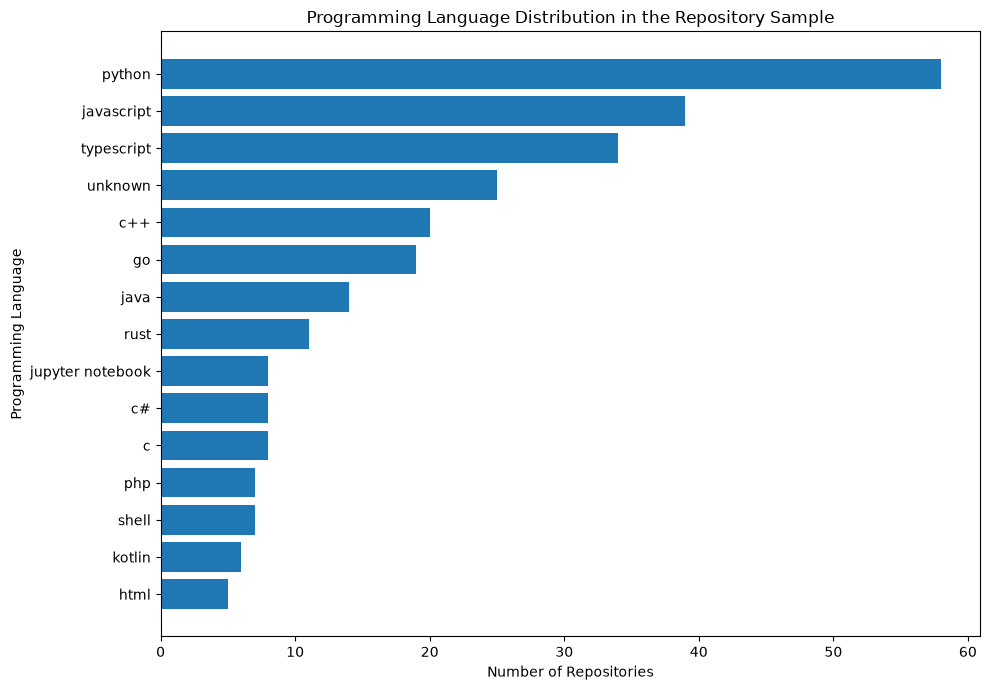

In [14]:
language_plot = (
    language_counts
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

plt.barh(
    language_plot.index,
    language_plot.values
)

plt.xlabel("Number of Repositories")
plt.ylabel("Programming Language")
plt.title(
    "Programming Language Distribution "
    "in the Repository Sample"
)

plt.tight_layout()
plt.show()

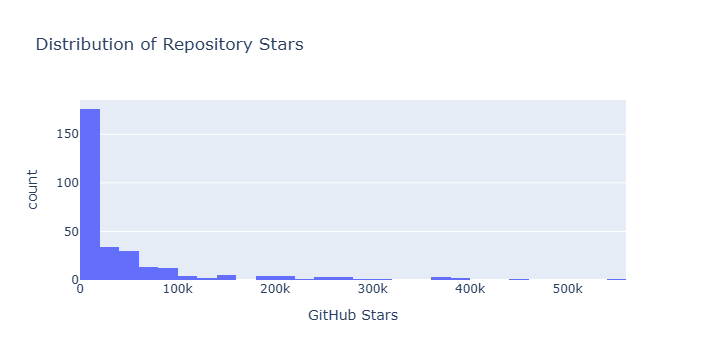

In [15]:
fig = px.histogram(
    df,
    x="stars",
    nbins=40,
    title="Distribution of Repository Stars",
    labels={
        "stars": "GitHub Stars"
    }
)

fig.show()

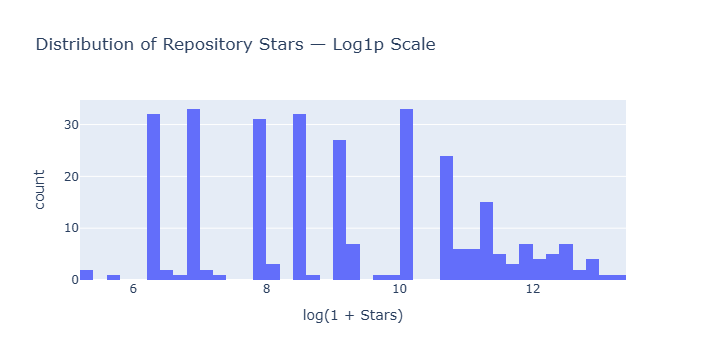

In [16]:
fig = px.histogram(
    df,
    x="log1p_stars",
    nbins=40,
    title="Distribution of Repository Stars — Log1p Scale",
    labels={
        "log1p_stars": "log(1 + Stars)"
    }
)

fig.show()

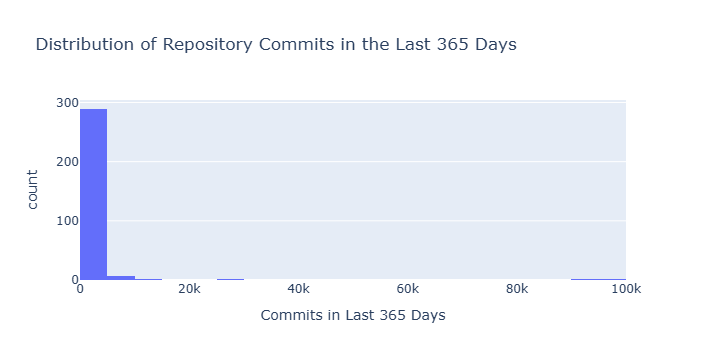

In [17]:
fig = px.histogram(
    df,
    x="commits_365d",
    nbins=40,
    title="Distribution of Repository Commits in the Last 365 Days",
    labels={
        "commits_365d": "Commits in Last 365 Days"
    }
)

fig.show()

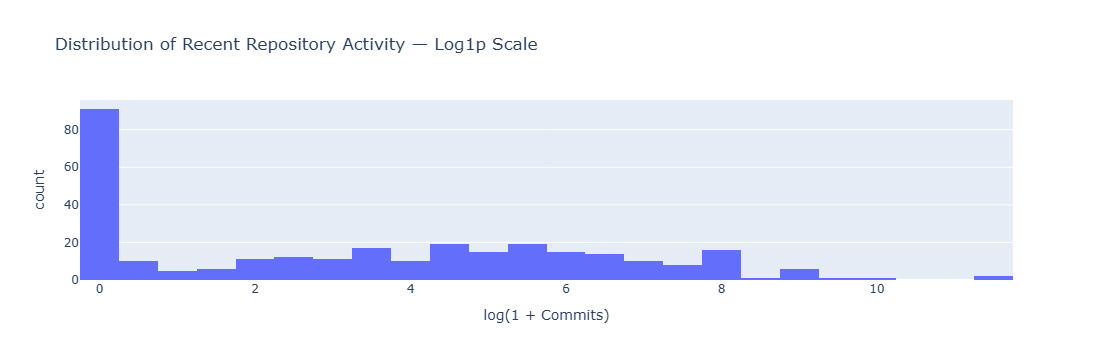

In [18]:
fig = px.histogram(
    df,
    x="log1p_commits_365d",
    nbins=40,
    title="Distribution of Recent Repository Activity — Log1p Scale",
    labels={
        "log1p_commits_365d": "log(1 + Commits)"
    }
)

fig.show()

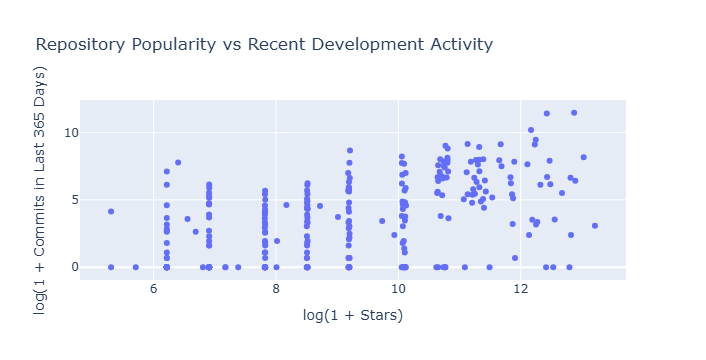

In [19]:
fig = px.scatter(
    df,
    x="log1p_stars",
    y="log1p_commits_365d",
    hover_name="full_name",
    hover_data=[
        "language_normalized",
        "stars",
        "commits_365d"
    ],
    title="Repository Popularity vs Recent Development Activity",
    labels={
        "log1p_stars": "log(1 + Stars)",
        "log1p_commits_365d": "log(1 + Commits in Last 365 Days)"
    }
)

fig.show()

In [20]:
correlation = df[
    ["log1p_stars", "log1p_commits_365d"]
].corr()

correlation

,log1p_stars,log1p_commits_365d
log1p_stars,1.000,0.521
log1p_commits_365d,0.521,1.000


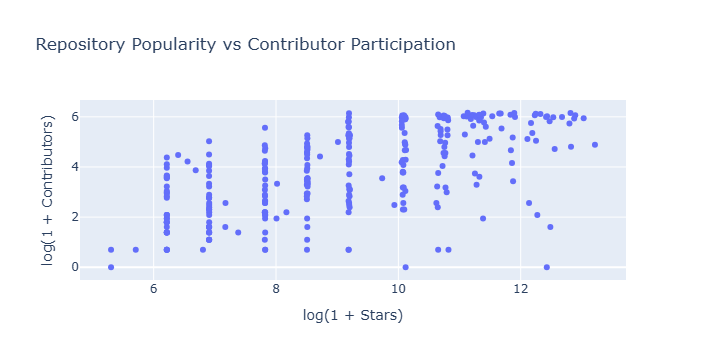

In [21]:
fig = px.scatter(
    df,
    x="log1p_stars",
    y="log1p_contributors_count",
    hover_name="full_name",
    hover_data=[
        "language_normalized",
        "stars",
        "contributors_count"
    ],
    title="Repository Popularity vs Contributor Participation",
    labels={
        "log1p_stars": "log(1 + Stars)",
        "log1p_contributors_count":
            "log(1 + Contributors)"
    }
)

fig.show()

In [22]:
df[
    ["log1p_stars", "log1p_contributors_count"]
].corr()

,log1p_stars,log1p_contributors_count
log1p_stars,1.000,0.614
log1p_contributors_count,0.614,1.000


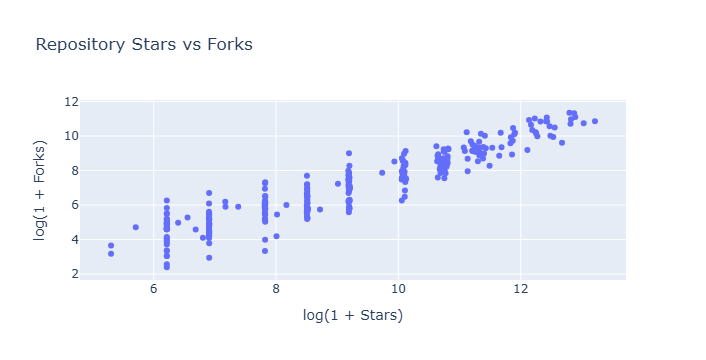

In [23]:
fig = px.scatter(
    df,
    x="log1p_stars",
    y="log1p_forks",
    hover_name="full_name",
    hover_data=[
        "language_normalized",
        "stars",
        "forks"
    ],
    title="Repository Stars vs Forks",
    labels={
        "log1p_stars": "log(1 + Stars)",
        "log1p_forks": "log(1 + Forks)"
    }
)

fig.show()

In [24]:
df[
    ["log1p_stars", "log1p_forks"]
].corr()

,log1p_stars,log1p_forks
log1p_stars,1.000,0.939
log1p_forks,0.939,1.000


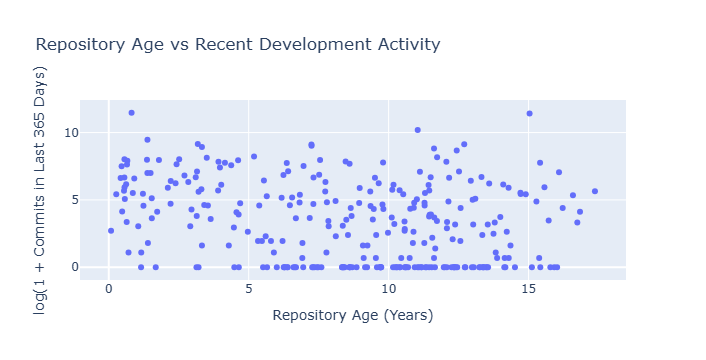

In [25]:
fig = px.scatter(
    df,
    x="repository_age_years",
    y="log1p_commits_365d",
    hover_name="full_name",
    hover_data=[
        "stars",
        "commits_365d",
        "language_normalized"
    ],
    title="Repository Age vs Recent Development Activity",
    labels={
        "repository_age_years": "Repository Age (Years)",
        "log1p_commits_365d":
            "log(1 + Commits in Last 365 Days)"
    }
)

fig.show()

In [26]:
df[
    ["repository_age_years", "log1p_commits_365d"]
].corr()

,repository_age_years,log1p_commits_365d
repository_age_years,1.000,-0.280
log1p_commits_365d,-0.280,1.000


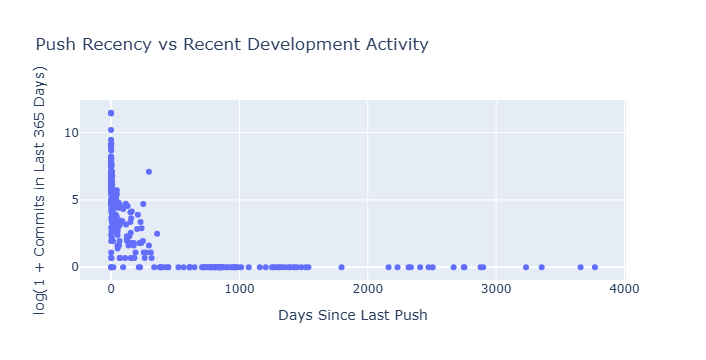

In [27]:
fig = px.scatter(
    df,
    x="days_since_push",
    y="log1p_commits_365d",
    hover_name="full_name",
    hover_data=[
        "stars",
        "commits_365d",
        "language_normalized"
    ],
    title="Push Recency vs Recent Development Activity",
    labels={
        "days_since_push": "Days Since Last Push",
        "log1p_commits_365d":
            "log(1 + Commits in Last 365 Days)"
    }
)

fig.show()

In [28]:
correlation_features = [
    "stars",
    "forks",
    "open_issues",
    "repository_age_days",
    "days_since_update",
    "days_since_push",
    "contributors_count",
    "total_contributions",
    "commits_365d",
    "active_months",
    "peak_monthly_commits",
    "mean_monthly_commits",
    "fork_star_ratio",
    "issues_per_star",
    "activity_consistency"
]

corr_matrix = df[
    correlation_features
].corr()

corr_matrix.round(2)

,stars,forks,open_issues,repository_age_days,days_since_update,days_since_push,contributors_count,total_contributions,commits_365d,active_months,peak_monthly_commits,mean_monthly_commits,fork_star_ratio,issues_per_star,activity_consistency
stars,1.000,0.900,0.290,-0.110,-0.290,-0.230,0.460,0.310,0.330,0.280,0.340,0.330,-0.050,-0.090,0.280
forks,0.900,1.000,0.330,-0.050,-0.260,-0.210,0.430,0.390,0.470,0.260,0.470,0.470,0.100,-0.060,0.260
open_issues,0.290,0.330,1.000,-0.070,-0.100,-0.090,0.300,0.590,0.190,0.060,0.190,0.190,0.030,0.220,0.060
repository_age_days,-0.110,-0.050,-0.070,1.000,0.140,0.240,0.070,0.050,-0.050,-0.180,-0.080,-0.060,0.070,0.040,-0.180
days_since_update,-0.290,-0.260,-0.100,0.140,1.000,0.560,-0.360,-0.160,-0.090,-0.450,-0.090,-0.090,0.190,0.120,-0.450
days_since_push,-0.230,-0.210,-0.090,0.240,0.560,1.000,-0.360,-0.160,-0.090,-0.570,-0.090,-0.090,0.140,0.000,-0.570
contributors_count,0.460,0.430,0.300,0.070,-0.360,-0.360,1.000,0.440,0.140,0.620,0.150,0.140,-0.030,0.010,0.620
total_contributions,0.310,0.390,0.590,0.050,-0.160,-0.160,0.440,1.000,0.470,0.320,0.490,0.480,0.040,0.200,0.320
commits_365d,0.330,0.470,0.190,-0.050,-0.090,-0.090,0.140,0.470,1.000,0.190,0.980,1.000,0.050,0.020,0.190
active_months,0.280,0.260,0.060,-0.180,-0.450,-0.570,0.620,0.320,0.190,1.000,0.190,0.180,-0.100,0.020,1.000


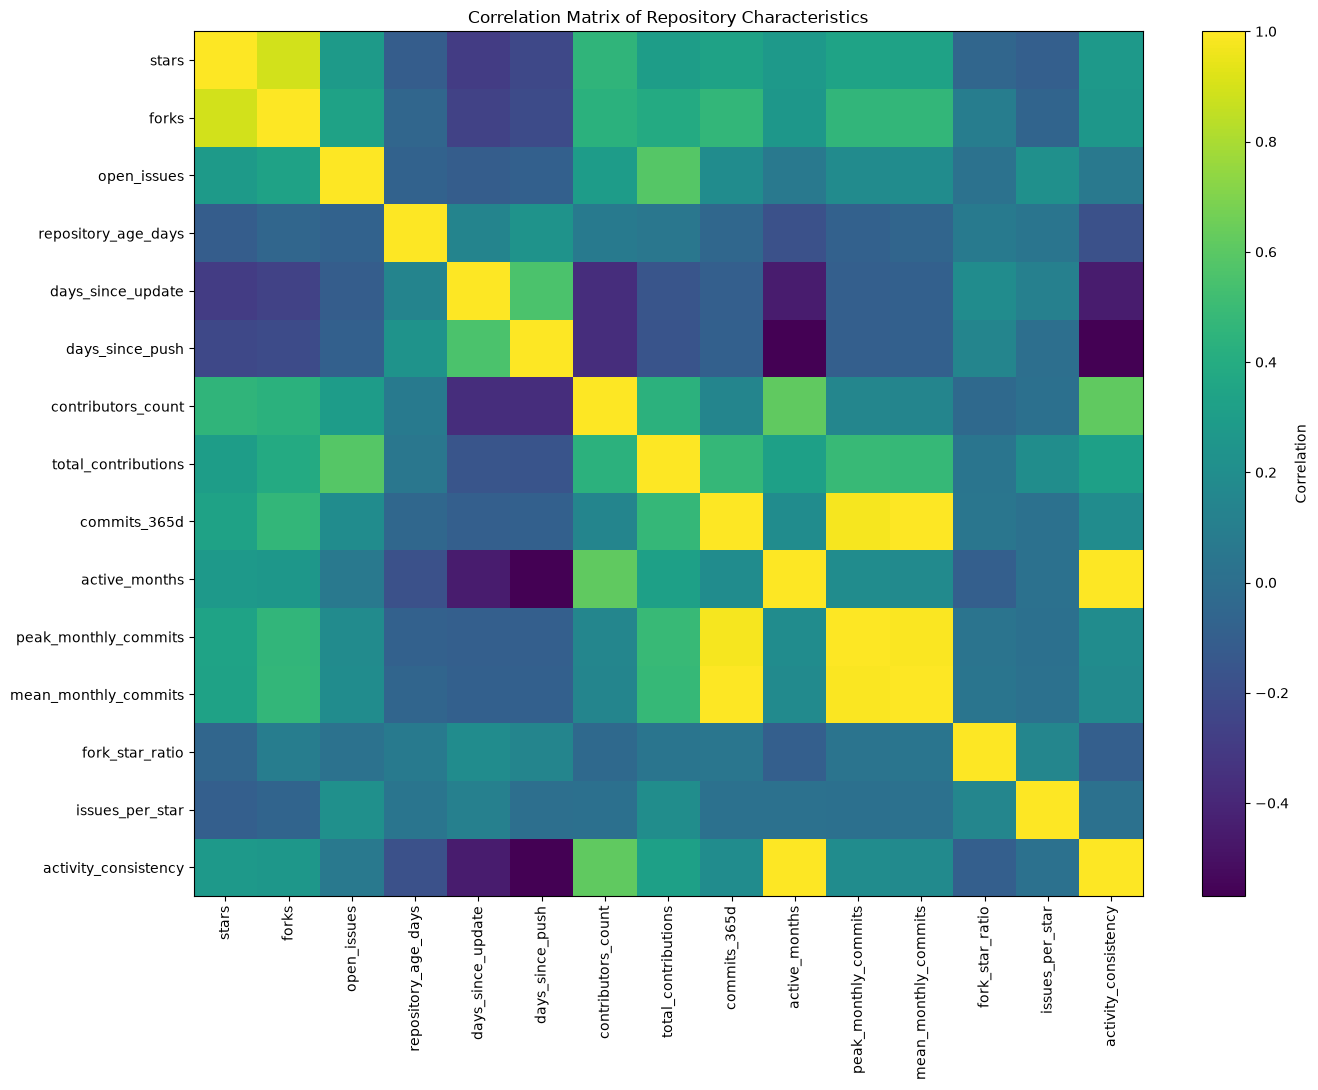

In [29]:
plt.figure(figsize=(14, 11))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.title(
    "Correlation Matrix of Repository Characteristics"
)

plt.tight_layout()
plt.show()

In [30]:
language_sample = (
    df["language_normalized"]
    .value_counts()
)

valid_languages = language_sample[
    language_sample >= 5
].index

language_df = df[
    df["language_normalized"].isin(valid_languages)
].copy()

print(
    "Languages included:",
    len(valid_languages)
)

print(
    language_df["language_normalized"]
    .value_counts()
)

Languages included: 16
language_normalized
python              58
javascript          39
typescript          34
unknown             25
c++                 20
go                  19
java                14
rust                11
c#                   8
c                    8
jupyter notebook     8
php                  7
shell                7
kotlin               6
html                 5
swift                5
Name: count, dtype: int64


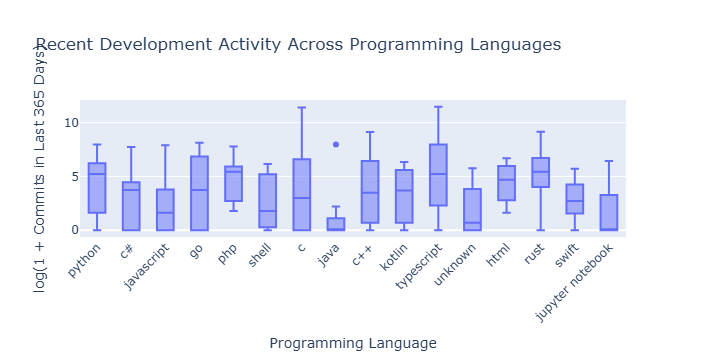

In [31]:
fig = px.box(
    language_df,
    x="language_normalized",
    y="log1p_commits_365d",
    points="outliers",
    title="Recent Development Activity Across Programming Languages",
    labels={
        "language_normalized": "Programming Language",
        "log1p_commits_365d":
            "log(1 + Commits in Last 365 Days)"
    }
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

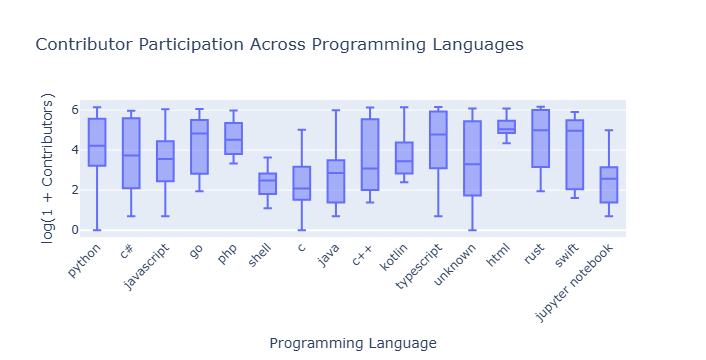

In [32]:
fig = px.box(
    language_df,
    x="language_normalized",
    y="log1p_contributors_count",
    points="outliers",
    title="Contributor Participation Across Programming Languages",
    labels={
        "language_normalized": "Programming Language",
        "log1p_contributors_count":
            "log(1 + Contributors)"
    }
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [33]:
language_summary = (
    language_df
    .groupby("language_normalized")
    .agg(
        repositories=("repo_id", "count"),
        median_stars=("stars", "median"),
        median_commits_365d=("commits_365d", "median"),
        median_contributors=("contributors_count", "median"),
        median_forks=("forks", "median"),
        median_age_years=("repository_age_years", "median")
    )
    .sort_values(
        "median_commits_365d",
        ascending=False
    )
)

language_summary

,repositories,median_stars,median_commits_365d,median_contributors,median_forks,median_age_years
language_normalized,,,,,,
rust,11,"24,816.000",227.000,147.000,"1,779.000",3.907
php,7,"2,499.000",226.000,91.000,233.000,13.002
typescript,34,"24,838.500",203.500,119.000,"2,193.500",6.679
python,58,"23,684.000",186.000,67.000,"2,495.000",5.509
html,5,"9,721.000",108.000,155.000,"2,954.000",10.393
kotlin,6,"4,948.000",48.000,34.500,578.500,9.258
c#,8,"3,741.500",44.000,44.000,324.000,10.376
go,19,"8,205.000",41.000,124.000,"1,076.000",8.605
c++,20,"4,984.000",37.500,21.500,551.000,11.209


In [34]:
activity_q1 = df["commits_365d"].quantile(0.25)
activity_q3 = df["commits_365d"].quantile(0.75)
activity_iqr = activity_q3 - activity_q1

activity_upper = activity_q3 + 1.5 * activity_iqr

high_activity = df[
    df["commits_365d"] > activity_upper
].copy()

print("Q1:", activity_q1)
print("Q3:", activity_q3)
print("IQR:", activity_iqr)
print("Upper IQR bound:", activity_upper)
print("High-activity outliers:", len(high_activity))

Q1: 0.0
Q3: 301.25
IQR: 301.25
Upper IQR bound: 753.125
High-activity outliers: 52


In [35]:
high_activity[
    [
        "full_name",
        "language_normalized",
        "stars",
        "commits_365d",
        "contributors_count",
        "active_months"
    ]
].sort_values(
    "commits_365d",
    ascending=False
).head(20)

,full_name,language_normalized,stars,commits_365d,contributors_count,active_months
284,openclaw/openclaw,typescript,389979,"96,177.000",377.000,11.000
16,torvalds/linux,c,249330,"90,201.000",0.000,13.000
101,microsoft/vscode,typescript,192634,"26,590.000",315.000,13.000
274,anomalyco/opencode,typescript,208133,"13,024.000",456.000,13.000
252,openinterpreter/openinterpreter,rust,68364,"9,498.000",474.000,13.000
54,godotengine/godot,c++,117364,"9,356.000",459.000,13.000
192,n8n-io/n8n,typescript,204985,"9,055.000",428.000,13.000
191,prisma/orm,typescript,47614,"8,256.000",23.000,12.000
248,lobehub/lobehub,typescript,82541,"7,510.000",348.000,13.000
81,metabase/metabase,clojure,49310,"6,755.000",391.000,13.000


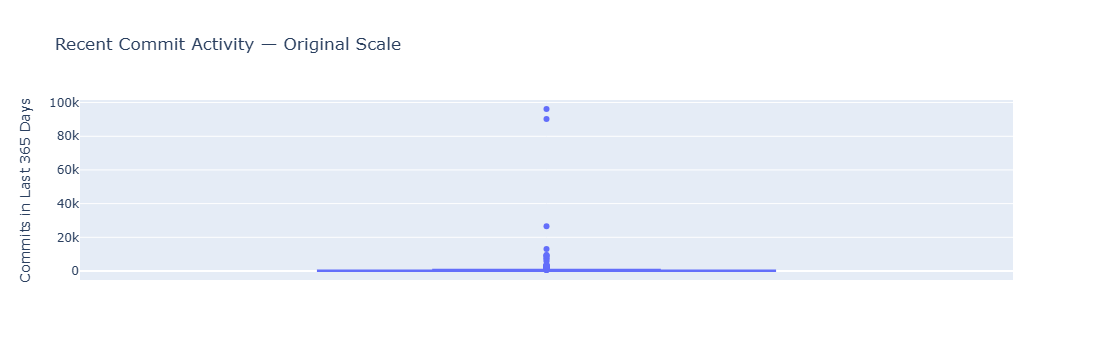

In [36]:
fig = px.box(
    df,
    y="commits_365d",
    points="outliers",
    title="Recent Commit Activity — Original Scale",
    labels={
        "commits_365d": "Commits in Last 365 Days"
    }
)

fig.show()

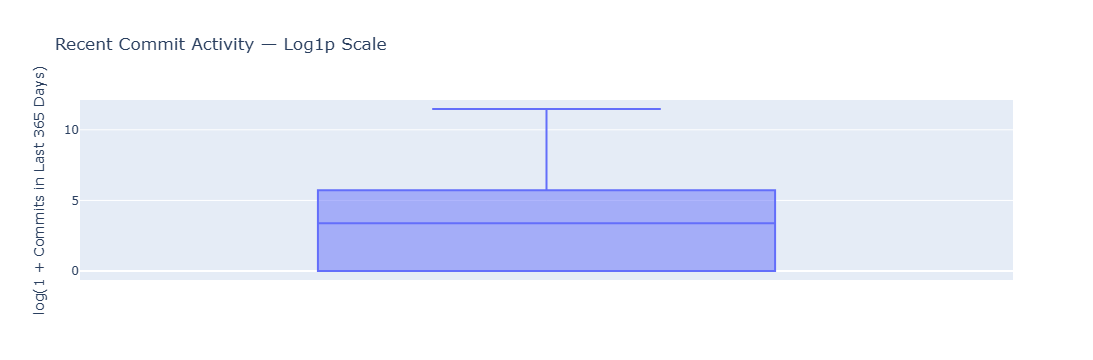

In [37]:
fig = px.box(
    df,
    y="log1p_commits_365d",
    points="outliers",
    title="Recent Commit Activity — Log1p Scale",
    labels={
        "log1p_commits_365d":
            "log(1 + Commits in Last 365 Days)"
    }
)

fig.show()

In [39]:
# Popularity groups
df["popularity_group"] = pd.qcut(
    df["stars"],
    q=4,
    labels=[
        "Q1 - Lower Popularity",
        "Q2",
        "Q3",
        "Q4 - Higher Popularity"
    ]
)

# Activity groups
# Separate repositories with zero recent commits
df["activity_group"] = "No Recent Activity"

positive_activity = df["commits_365d"] > 0

df.loc[positive_activity, "activity_group"] = pd.qcut(
    df.loc[positive_activity, "commits_365d"],
    q=4,
    labels=[
        "Q1 - Lower Activity",
        "Q2",
        "Q3",
        "Q4 - Higher Activity"
    ]
).astype(str)

print("Popularity groups:")
print(df["popularity_group"].value_counts().sort_index())

print("\nActivity groups:")
print(df["activity_group"].value_counts())

Popularity groups:
popularity_group
Q1 - Lower Popularity     76
Q2                        74
Q3                        75
Q4 - Higher Popularity    75
Name: count, dtype: int64

Activity groups:
activity_group
No Recent Activity      91
Q1 - Lower Activity     54
Q3                      52
Q4 - Higher Activity    52
Q2                      51
Name: count, dtype: int64


In [40]:
popularity_activity_table = pd.crosstab(
    df["popularity_group"],
    df["activity_group"],
    normalize="index"
) * 100

popularity_activity_table.round(2)

activity_group,No Recent Activity,Q1 - Lower Activity,Q2,Q3,Q4 - Higher Activity
popularity_group,,,,,
Q1 - Lower Popularity,57.890,18.420,13.160,7.890,2.630
Q2,28.380,27.030,28.380,14.860,1.350
Q3,24.000,20.000,17.330,21.330,17.330
Q4 - Higher Popularity,10.670,6.670,9.330,25.330,48.000


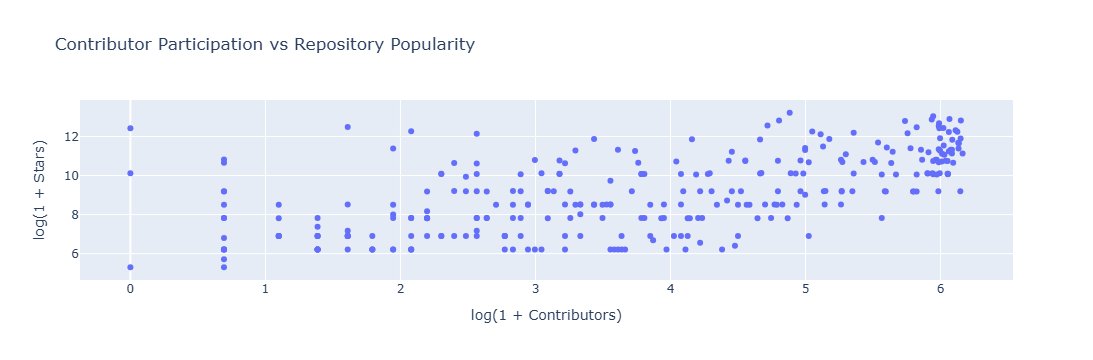

In [41]:
fig = px.scatter(
    df,
    x="log1p_contributors_count",
    y="log1p_stars",
    hover_name="full_name",
    hover_data=[
        "language_normalized",
        "stars",
        "contributors_count"
    ],
    title="Contributor Participation vs Repository Popularity",
    labels={
        "log1p_contributors_count": "log(1 + Contributors)",
        "log1p_stars": "log(1 + Stars)"
    }
)

fig.show()

In [42]:
df[
    ["log1p_contributors_count", "log1p_stars"]
].corr()

,log1p_contributors_count,log1p_stars
log1p_contributors_count,1.000,0.614
log1p_stars,0.614,1.000


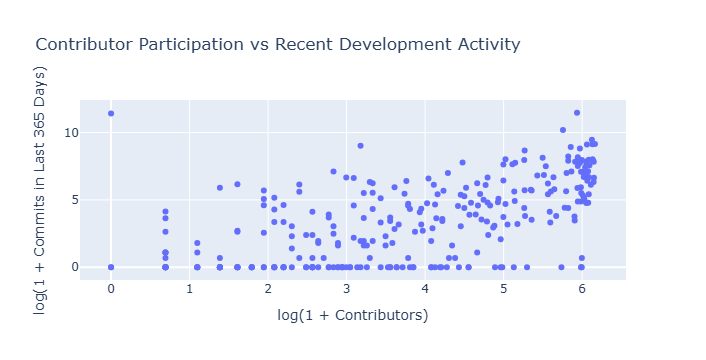

In [43]:
fig = px.scatter(
    df,
    x="log1p_contributors_count",
    y="log1p_commits_365d",
    hover_name="full_name",
    hover_data=[
        "stars",
        "contributors_count",
        "commits_365d"
    ],
    title="Contributor Participation vs Recent Development Activity",
    labels={
        "log1p_contributors_count": "log(1 + Contributors)",
        "log1p_commits_365d": "log(1 + Commits in Last 365 Days)"
    }
)

fig.show()

In [44]:
df[
    ["log1p_contributors_count", "log1p_commits_365d"]
].corr()

,log1p_contributors_count,log1p_commits_365d
log1p_contributors_count,1.000,0.596
log1p_commits_365d,0.596,1.000


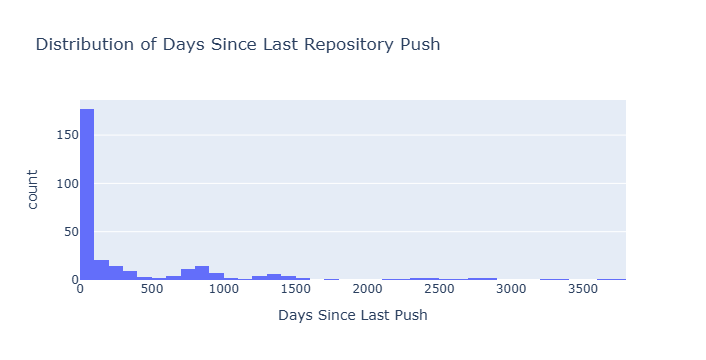

In [45]:
fig = px.histogram(
    df,
    x="days_since_push",
    nbins=40,
    title="Distribution of Days Since Last Repository Push",
    labels={
        "days_since_push": "Days Since Last Push"
    }
)

fig.show()

In [46]:
df["days_since_push"].describe()

count     300.000
mean      388.317
std       702.090
min         0.000
25%         2.000
50%        42.000
75%       466.500
max     3,770.000
Name: days_since_push, dtype: float64

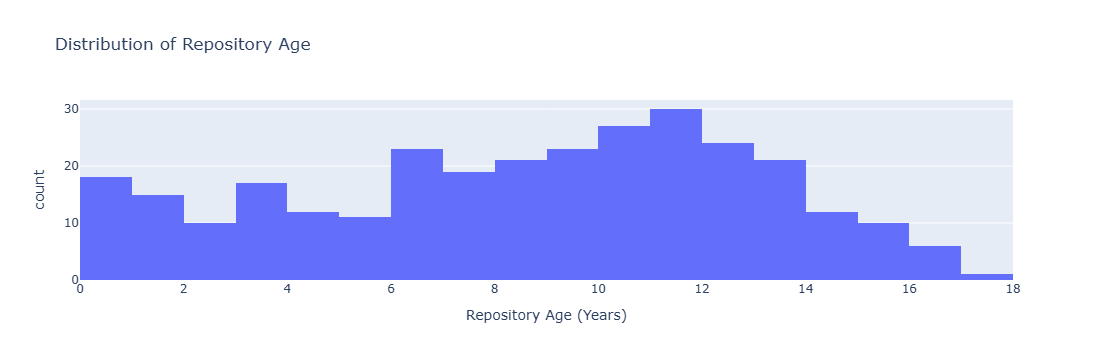

In [47]:
fig = px.histogram(
    df,
    x="repository_age_years",
    nbins=30,
    title="Distribution of Repository Age",
    labels={
        "repository_age_years": "Repository Age (Years)"
    }
)

fig.show()

In [48]:
df["repository_age_years"].describe()

count   300.000
mean      8.567
std       4.373
min       0.082
25%       5.449
50%       9.236
75%      11.791
max      17.372
Name: repository_age_years, dtype: float64

In [49]:
research_correlations = pd.DataFrame({
    "Relationship": [
        "Popularity ↔ Activity",
        "Popularity ↔ Contributors",
        "Popularity ↔ Forks",
        "Age ↔ Activity",
        "Push Recency ↔ Activity",
        "Contributors ↔ Activity"
    ],
    "Correlation": [
        df["log1p_stars"].corr(
            df["log1p_commits_365d"]
        ),
        df["log1p_stars"].corr(
            df["log1p_contributors_count"]
        ),
        df["log1p_stars"].corr(
            df["log1p_forks"]
        ),
        df["repository_age_years"].corr(
            df["log1p_commits_365d"]
        ),
        df["days_since_push"].corr(
            df["log1p_commits_365d"]
        ),
        df["log1p_contributors_count"].corr(
            df["log1p_commits_365d"]
        )
    ]
})

research_correlations.round(3)

,Relationship,Correlation
0,Popularity ↔ Activity,0.521
1,Popularity ↔ Contributors,0.614
2,Popularity ↔ Forks,0.939
3,Age ↔ Activity,-0.280
4,Push Recency ↔ Activity,-0.591
5,Contributors ↔ Activity,0.596


In [50]:
research_correlations.to_csv(
    "../reports/research_question_correlations.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.
